In [45]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Numerical Data

In [8]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [33]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [34]:
x_train , x_test ,y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [35]:
# to make the changes lets make a new column for imputated age using the Age col
# Age == Age_imputed 

In [36]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [37]:
x_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [39]:
# Replace NaN == Random Values 
x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age_imputed'].isnull().sum()).values

C:\Users\Shubham\AppData\Local\Temp\ipykernel_16240\2825447425.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()

### Lets break down this Code   

**Goal** : Replace the NaN Value w the Random Value (but the range of random value should be from That colum only)    

**x_train['Age_imputed'][x_train['Age_imputed'].isnull()]**     --->    Select Age imputed from x_train where Age imputed is Null(NaN)  

 
Now we replace the missing NaN with random Value   
**x_train['Age'].dropna()**    --->   Means Drop all null values from Age coln (It will Act as a Range for Imputing the Random Value)



**.sample(x_train['Age_imputed'].isnull().sum())**   - --> Means Random Sample Should be Selected from the Given Set of Numbers only (Which we have find , in last step),use sum to get numbers (Default is Boolean Value) )   


**.values**  --> We'll get all Unique Values that are present in the column.


In [38]:
# Random Values to Impute (Just for Visual)
x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values

array([32.  , 21.  , 50.  , 14.  , 27.  , 24.  , 35.  , 33.  , 33.  ,
       34.  , 24.  , 21.  , 31.  , 57.  , 25.  , 65.  ,  1.  , 18.  ,
       11.  , 16.  , 31.  , 18.  , 34.  , 25.  , 28.  , 30.  , 10.  ,
       29.  , 49.  , 31.  , 49.  , 31.  , 16.  , 26.  , 35.  , 41.  ,
       24.  , 34.  , 24.  ,  8.  , 60.  , 39.  , 29.  , 20.  , 16.  ,
        7.  , 45.  , 18.  , 28.  , 28.  , 32.  , 61.  , 24.  , 27.  ,
       20.  , 26.  , 21.  , 23.  , 19.  , 28.  , 30.  , 25.  , 62.  ,
       70.5 , 38.  , 34.  , 16.  ,  3.  ,  9.  , 30.  , 22.  , 34.5 ,
       28.5 , 39.  , 30.  , 23.  , 58.  , 30.  ,  0.75, 17.  , 33.  ,
       22.  , 16.  , 17.  , 28.  , 26.  , 19.  , 21.  , 36.  , 23.  ,
       40.  , 36.  , 50.  , 38.  , 33.  ,  4.  , 32.  , 46.  , 27.  ,
       40.  , 66.  ,  5.  ,  4.  , 41.  , 30.  , 18.  , 30.  , 18.  ,
       44.  ,  2.  , 28.  , 30.  , 40.  , 39.  ,  1.  , 22.  , 23.  ,
       39.  , 18.  , 32.  , 33.  , 59.  , 24.  , 45.  , 22.  , 32.  ,
       24.  , 11.  ,

In [40]:
# How many Null values were there ? 
x_train['Age'].isnull().sum()

np.int64(148)

In [42]:
# Lets check our Random Imputation
x_train.tail()

,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,35.0
493,71.0,49.5042,71.0
527,NaN,221.7792,24.0
168,NaN,25.9250,49.0


In [43]:
# All NaN are replaced by the random Value

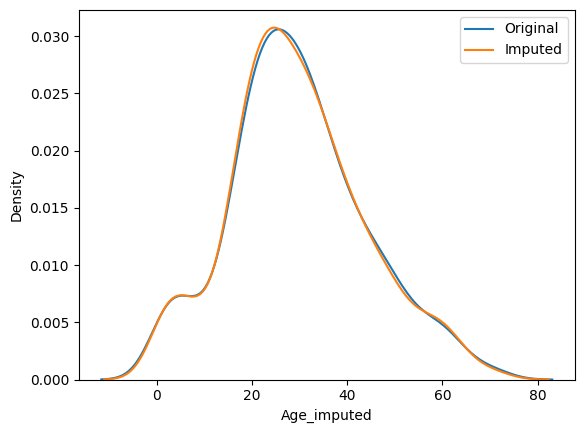

In [52]:
# Lets check the Distribution 
sns.distplot(x_train['Age'],label= 'Original',hist=False)
sns.distplot(x_train['Age_imputed'],label='Imputed',hist=False) 

plt.legend()  
plt.show();

In [53]:
# One of the Advantages of using random Imputation is , it doesn't changes the Distribution 

In [54]:
# Lets check the Varaince 
print('Original variable variance: ', x_train['Age'].var())
print('Variance after random imputation: ', x_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  202.3263328764278


In [55]:
# Covariance
x_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.166847
Age,71.512440,204.349513,204.349513
Age_imputed,57.166847,204.349513,202.326333


In [59]:
# Cov has changed for Fare Value a lot (Not Good ) -> Dont Apply Random Imputation , others GOOD

<Axes: >

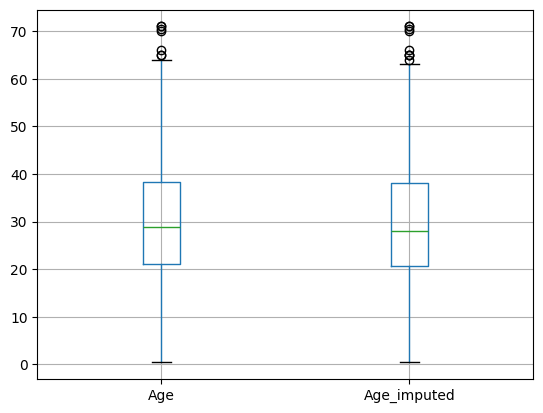

In [62]:
# Boxplot 
x_train[['Age', 'Age_imputed']].boxplot()   # NO major changes  -> GOOD

##  Categorical Data

In [66]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [67]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [68]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [69]:
# Imputing ~48% data might cause some troubles 

In [71]:
x = data  # Using All cols i'll need Sale Price Col for Visuals 
y = data['SalePrice']

In [72]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [73]:
# Repeating same steps as above 
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [75]:
x_train.sample(5)
# Cone Done

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
754,NaN,TA,156000,TA,NaN
1447,TA,TA,240000,TA,TA
883,NaN,TA,118500,TA,NaN
214,NaN,TA,161750,TA,NaN
967,NaN,TA,135000,TA,NaN


In [78]:
# Random Imputation 
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

In [77]:
# Set of Random Value to Impute
x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

array(['TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA'], dtype=object)

In [80]:
x_train.sample(5)
# all NaN are placed with random Value

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
515,Gd,TA,402861,TA,Gd
1446,NaN,TA,157900,TA,Gd
564,TA,TA,268000,TA,TA
1255,Gd,TA,127500,TA,Gd
804,NaN,TA,118000,TA,TA


In [89]:
# Lets Compare both cols Original & Imputated 
# GarageQual

temp = pd.concat(                     # To Join Both Arrays                          
        [
            x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),     #here deno is Dropna() -> reason (a)
            x_train['GarageQual_imputed'].value_counts() / len(x_train)                     # here deno is whole col 
        ],
        axis=1)

temp.columns = ['original', 'imputed']               # Col headings 

# (a) Use dropna() in denominator to get the actual category percentages without missing values.
# If we divide by total rows, null values also get included, which is not the distribution we want.

In [90]:
# GarageQual
temp           # Not much Changes coz Missing Values were ~5% only , using Random Imputation -> GOOD

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [91]:
# FireplaceQu

temp = pd.concat(
        [
            x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
            x_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [92]:
# FireplaceQu
temp   # We have Lot of changes coz the missing values were ~48% , using Random Imputation -> Not GOOD

,original,imputed
Gd,0.494272,0.649832
TA,0.412439,0.540965
Fa,0.040917,0.052750
Po,0.027823,0.034792
Ex,0.024550,0.032548


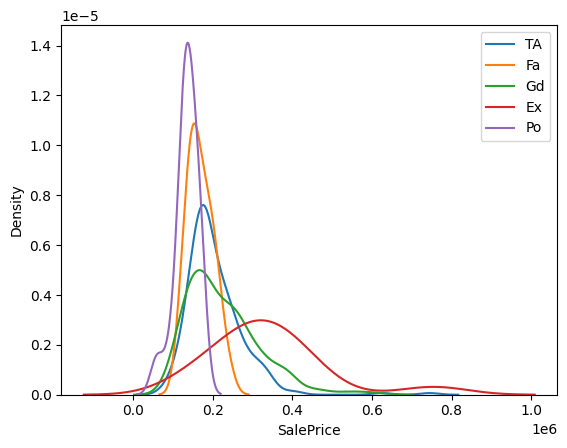

In [95]:
# Lets Visualise 

# Before Imputation 
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)

    # sns.distplot(x,y)
plt.legend()    
plt.show()

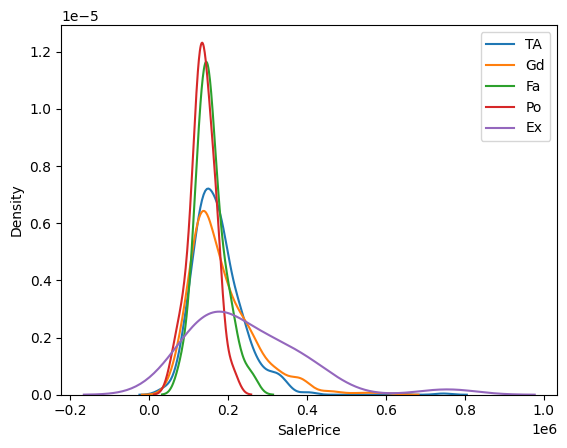

In [97]:
# After Imputation : 
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.legend()    
plt.show()

In [98]:
# All the values are chnaged drastically --> NOT GOOOD 